In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from modules.backtestdata import DataBuilder, DataLoader
from modules.strategies import MetaStrategy, FixedWeights, Markowitz, asset_plot
from modules.simulator import BacktestSimulator, wealth_plot
from modules.riskmodel import Riskmodel

In [2]:
riskmodel = Riskmodel.load_from_npz("../data/riskmodel/k10_lb6m_hc6m_hv2m.npz")
return_d = pd.read_parquet("../data/return/return_d.parquet")
rf_d     = pd.read_parquet("../data/return/ffr_d.parquet")
print(return_d.shape, rf_d.shape)

# placeholder alpha
alpha_d = return_d.copy()
alpha_d[:] = 1.0
print(alpha_d.shape)

(8344, 47) (26200, 1)
(8344, 47)


In [3]:
# TODO Implementations:
# - Add d_var to dataloader, used to compute full risk in markowitz and vol control
# - Double triple check for lookahead from riskmodel
# - Carefully go though dataloader, any potential misalignment?

FIRST_DATE = "2005-01-03"
FINAL_DATE = "2024-12-31"
SPREAD = 5e-4
LEVERAGE = 0.0
VC_LIMIT = 0.08 # float("inf")
REBAL_FREQ = "M"

sim = BacktestSimulator(SPREAD)

db = DataBuilder(
    universe=return_d.columns,
    first_date=FIRST_DATE,
    final_date=FINAL_DATE,
    alpha_d=alpha_d,
    return_d=return_d,
    rf_d=rf_d,
    riskmodel=riskmodel,
    rebal_freq=REBAL_FREQ,
)
print(db)

2005-01-03 : 2024-12-31
 :a  - (5033, 47), <class 'numpy.ndarray'>
 :r  - (5033, 47), <class 'numpy.ndarray'>
 :rf - (5033,), <class 'numpy.ndarray'>
 :F  - (5033, 47, 10), <class 'numpy.ndarray'>
 :d  - (5033, 47), <class 'numpy.ndarray'>
 :am - (5033, 47), <class 'numpy.ndarray'>
 :tf - (5033,), <class 'numpy.ndarray'>
 :universe - Index(['AGG', 'BTC-USD', 'CANE', 'CORN', 'CPER', 'DBA', 'DBB', 'DBC', 'EEM',
       'EWA', 'EWC', 'EWD', 'EWG', 'EWH', 'EWJ', 'EWL', 'EWP', 'EWS', 'EWT',
       'EWU', 'EWW', 'EWY', 'EWZ', 'GLD', 'IBB', 'IYR', 'LQD', 'PPLT', 'QQQ',
       'SLV', 'SOYB', 'SPY', 'TIP', 'TLT', 'UNG', 'USO', 'WEAT', 'WOOD', 'XLB',
       'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY'],
      dtype='str', name='Ticker')


Backtest Runtime: 1295 ms
Ann Sharpe: 0.7252
Tot Ret:    3.4987
Ann Ret:    0.0782
Ann Vol:    0.0835
Max DD :    0.19


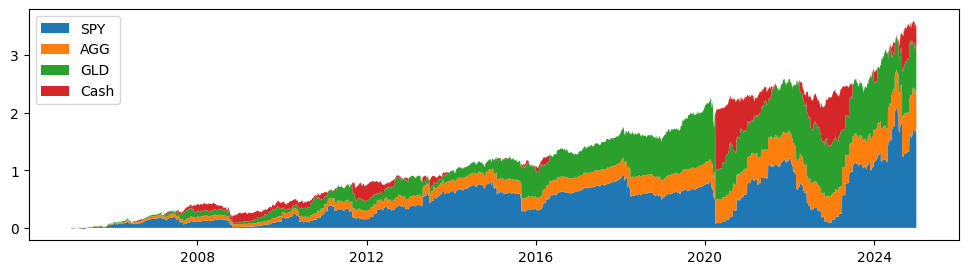

In [4]:
sbg = ["SPY", "AGG", "GLD"]
dl = DataLoader(db=db, tickers=sbg)

m1 = Markowitz(
    dl=dl,
    lookahead=0,
    gamma=SPREAD,
    lev=LEVERAGE,
    w_max=np.array([0.7, 0.2, 0.7]),
    vc_lim=VC_LIMIT,
)
sim.run_backtest(strategy=m1, verbose=True)
wealth_plot(sim)

# equal_weights = np.ones(dl.N)/dl.N
# fw = FixedWeights(
#     dl=dl,
#     w_rebal=equal_weights,
#     lev=LEVERAGE,
#     vc_lim=VC_LIMIT,
# )
# sim.run_backtest(strategy=fw, verbose=True)
# wealth_plot(sim)

Backtest Runtime: 1383 ms
Ann Sharpe: 0.5232
Tot Ret:    2.856
Ann Ret:    0.0699
Ann Vol:    0.1001
Max DD :    0.2936


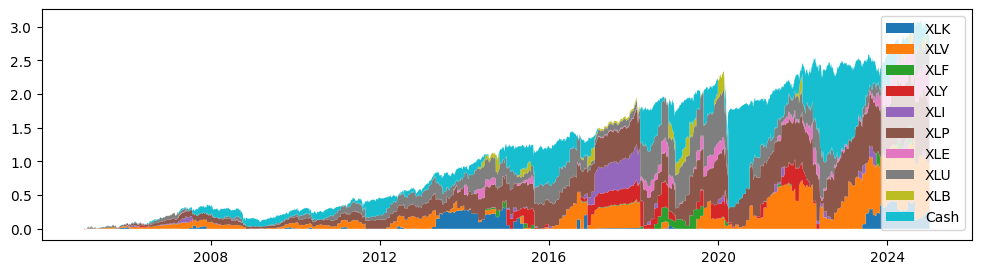

In [5]:
sectors = ["XLK", "XLV", "XLF", "XLY", "XLI", "XLP", "XLE", "XLU", "XLB"]
dl = DataLoader(db=db, tickers=sectors)

m2 = Markowitz(
    dl=dl,
    lookahead=0,
    gamma=SPREAD,
    lev=LEVERAGE,
    w_max=0.3*np.ones(dl.N),
    vc_lim=VC_LIMIT,
)
sim.run_backtest(strategy=m2, verbose=True)
wealth_plot(sim)

Backtest Runtime: 2690 ms
Ann Sharpe: 0.7247
Tot Ret:    3.3908
Ann Ret:    0.0769
Ann Vol:    0.0818
Max DD :    0.1829


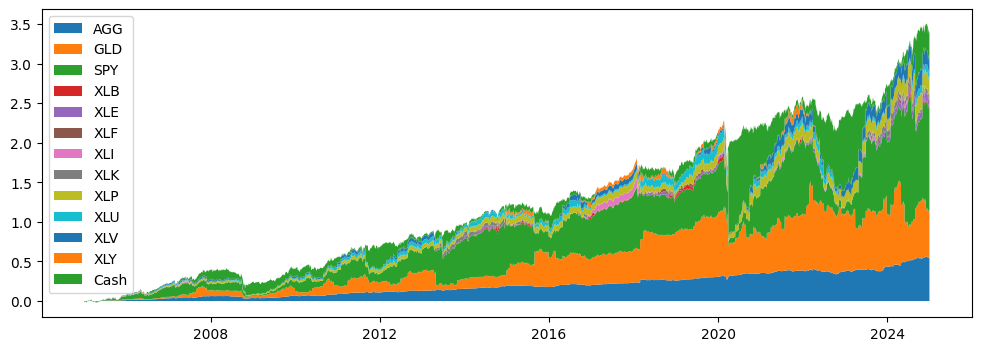

In [6]:
ms = MetaStrategy(
    db=db,
    strategies=[m1, m2],
    w_blend=np.array([0.8, 0.2]),
)
sim.run_backtest(strategy=ms, verbose=True)
wealth_plot(sim, figsize=(12,4))

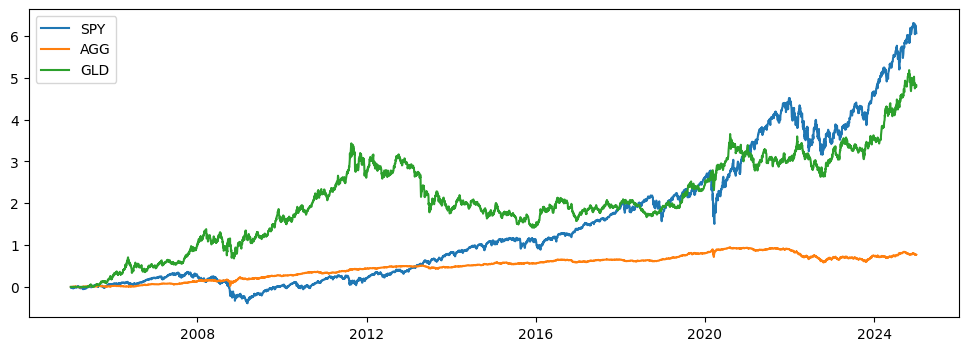

In [7]:
asset_plot(m1, figsize=(12, 4))

In [8]:
# riskmodel/k10_lb6m_hc6m_hv2m.npz
# FIRST_DATE = "2005-01-03"
# FINAL_DATE = "2024-12-31"
# SPREAD = 5e-4
# LEVERAGE = 0.0
# VC_LIMIT = 0.08
# REBAL_FREQ = "M"
# m = Markowitz(
#     dl=dl,
#     lookahead=0,
#     gamma=SPREAD,
#     lev=LEVERAGE,
#     w_max=np.array([0.7, 0.2, 0.7, 0.7]),
#     vc_lim=VC_LIMIT,
# )
# Backtest Runtime: 1292 ms
# Ann Sharpe: 0.8134
# Ann Ret:    0.0873
# Ann Vol:    0.0855

In [9]:
# from time import time
# start = time()
# for i in range(100):
#     run_backtest(
#         strategy=fw,
#         spread=SPREAD
#     )
# print(time() - start)

In [10]:
# tickers = ["LQD", "SMH", "XLK", "AGG"] # , "QQQ", "GLD", "AGG", "XLK"
# # tickers = ["QQQ", "AGG", "XLK"]
# for t in tickers:
#     assert t in assets_remaining

# op = mod.OptimizerParams(
#     w_prev=np.zeros(len(tickers)),
#     w_max=0.7,
#     gamma=2e-4,
#     L=0.0,
#     vc_lim=((1.08)**(1/252))-1.0,
# )

# # data_bt["alpha"] = np.ones_like(data_bt["alpha"])

# lookahead = 0  # months
# holdings: pd.DataFrame = mod.run_backtest(
#     tickers=tickers,
#     universe=rd.columns,
#     data_bt=data_bt,
#     lookahead=lookahead,
#     op=op,
#     fixed_weights=False,
# )

# # r_tot = (performance+1).prod() - 1 
# # w_avg = weights.round(3).mean(axis=0).round(3)
# # vol_ann = performance.std() * 12**0.5 * 100 # realized

# # print(f"Sharpe ratio: {sharpe:8.3f}")
# # print(f"Period return: {r_tot:7.3f}")
# # print(f"Avg weights: {w_avg}")
# # print(f"Realized vol: {vol_ann:7.3}%")
# # print(f"Period: {START_DATE} : {END_DATE}")

# nav = holdings.sum(axis=1)
# w_port = holdings.div(nav, axis=0)

# rp = nav.pct_change().dropna()
# rf = ffr["DFF"].reindex(rp.index)
# mod.sharpe_ratio(rp, rf).round(3).item()

In [11]:
# |------------.------.---.--.-|-|
#                              t 
# The first 2 years (minus a day) are lost due to lookback (trailing returns)
# The last 1 month is lost due to trying to predict the future month - no lookahead!

# # plotting thetas over time
# features_all = ["Const"] + features_ret + features_mac
# pd.DataFrame(theta.mean(axis=1), columns=features_all, index=df_ref.index).plot()
# plt.show()

# # plotting pca graph
# Am = data[assets_remaining[0]]
# Um, d, VmT = np.linalg.svd(Am)
# Um.shape, d.shape, VmT.shape
# d /= d.sum()

# plt.figure(figsize=(7,2))
# plt.plot(d.cumsum())
# plt.axhline(y=0.90, c="r")
# plt.title(f"PCA - {assets_remaining[0]}")
# # plt.axvline(x=8, c="k", ls=":")
# plt.show()

In [12]:
# NOTE Simple way of getting an alpha

# rd = rd.loc[START_DATE:END_DATE]
# rd = rd.loc[:, ~rd.isna().any(axis=0)]

# corr = rd.rolling(252).corr().dropna()
# corr_avg = corr.groupby(level=0).apply(lambda x: (x - np.eye(rd.shape[1])).mean(axis=0).abs())
# corr_avg

# ffr = ffr.reindex(rd.index)
# excess = rd.sub(ffr.values, axis=0)
# mu = excess.rolling(252).mean().dropna()
# sd = rd.rolling(252).std().dropna()
# shrp_sld = mu / sd * np.sqrt(252)

# beta = 1.0
# gamma = 1.0
# alphas = beta * shrp_sld - gamma * corr_avg
# rd = rd.reindex(alphas.index)

In [13]:
# alphas = df_prd.rank(axis=1)
# rd = rd.loc[alphas.index, assets_remaining]

# assert rd.isna().any().any() == False

# ffr = (ffr + 1)**(1/252) - 1  # transform to daily
# ffr = ffr.reindex(rd.index)
# assert ffr.isna().any().any() == False

# lookback = 42 # days
# data_bt = backtest_data(
#     alphas=alphas,
#     rd=rd,
#     ffr=ffr,
#     lookback=lookback, 
#     rebal_freq="M"
#     )
# data_bt.keys()